In [1]:
import os
import h5py
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split, KFold
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
DATA_PATH = "/kaggle/input/datasets/anhoangvo/acdc-dataset/ACDC_preprocessed/ACDC_training_slices"

IMG_SIZE = (256, 256)
NUM_CLASSES = 4
BATCH_SIZE = 8

RESULTS_DIR = "/kaggle/working/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Dataset path:", DATA_PATH)
print("Results directory:", RESULTS_DIR)

Dataset path: /kaggle/input/datasets/anhoangvo/acdc-dataset/ACDC_preprocessed/ACDC_training_slices
Results directory: /kaggle/working/results


# Dataset Structure


In [3]:
files = [
    f for f in os.listdir(DATA_PATH)
    if f.endswith(".h5")
]

print("Total H5 files:", len(files))
print("\nFirst 5 files:")

for f in files[:5]:
    print(f)

Total H5 files: 1912

First 5 files:
patient061_frame01_slice_7.h5
patient067_frame10_slice_0.h5
patient050_frame12_slice_6.h5
patient045_frame01_slice_7.h5
patient007_frame01_slice_5.h5


# Inspect One H5 File

In [4]:

file_name = files[0]
file_path = os.path.join(DATA_PATH, file_name)

print("File:", file_name)

with h5py.File(file_path, "r") as f:

    print("\nKeys:")
    print(list(f.keys()))

    for key in f.keys():
        print(
            f"{key}: "
            f"shape={f[key].shape}, "
            f"dtype={f[key].dtype}"
        )

File: patient061_frame01_slice_7.h5

Keys:
['image', 'label', 'scribble']
image: shape=(256, 216), dtype=float32
label: shape=(256, 216), dtype=uint8
scribble: shape=(256, 216), dtype=uint16


# Visualize MRI and Expert Segmentation

Image shape: (256, 216)
Label shape: (256, 216)
Labels: [0 1 2 3]


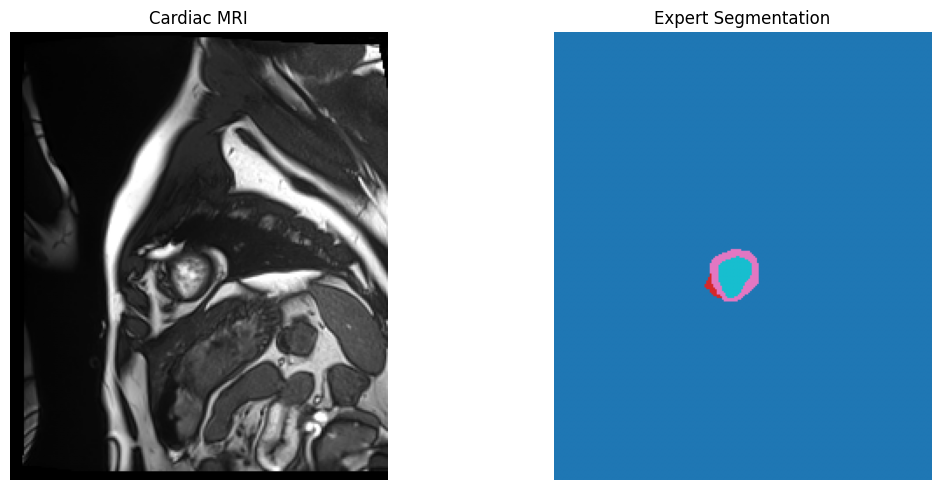

In [5]:
file_name = "patient061_frame01_slice_7.h5"
file_path = os.path.join(DATA_PATH, file_name)

with h5py.File(file_path, "r") as f:
    image = f["image"][:]
    label = f["label"][:]

print("Image shape:", image.shape)
print("Label shape:", label.shape)
print("Labels:", np.unique(label))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Cardiac MRI")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(label, cmap="tab10", vmin=0, vmax=3)
plt.title("Expert Segmentation")
plt.axis("off")

plt.tight_layout()
plt.show()

# Load Entire Dataset

In [6]:
images = []
labels = []
patient_ids = []

for file_name in files:

    patient_id = file_name.split("_")[0]

    file_path = os.path.join(DATA_PATH, file_name)

    with h5py.File(file_path, "r") as f:
        image = f["image"][:]
        label = f["label"][:]

    image = cv2.resize(
        image,
        IMG_SIZE,
        interpolation=cv2.INTER_LINEAR
    )

    label = cv2.resize(
        label,
        IMG_SIZE,
        interpolation=cv2.INTER_NEAREST
    )

    images.append(image)
    labels.append(label)
    patient_ids.append(patient_id)

images = np.array(images, dtype=np.float32)
labels = np.array(labels, dtype=np.uint8)
patient_ids = np.array(patient_ids)

print("Dataset loaded!")
print("Images:", images.shape)
print("Labels:", labels.shape)
print("Patients:", len(np.unique(patient_ids)))
print("Classes:", np.unique(labels))

Dataset loaded!
Images: (1912, 256, 256)
Labels: (1912, 256, 256)
Patients: 100
Classes: [0 1 2 3]


# Dataset Analysis

In [7]:
unique, counts = np.unique(labels, return_counts=True)

print("Pixel distribution:\n")

for value, count in zip(unique, counts):

    percentage = count / labels.size * 100

    print(
        f"Class {value}: "
        f"{count:,} pixels "
        f"({percentage:.2f}%)"
    )

print("\nImage statistics")

print("Minimum:", images.min())
print("Maximum:", images.max())
print("Mean:", images.mean())
print("Std:", images.std())

Pixel distribution:

Class 0: 120,534,568 pixels (96.19%)
Class 1: 1,580,197 pixels (1.26%)
Class 2: 1,593,582 pixels (1.27%)
Class 3: 1,596,485 pixels (1.27%)

Image statistics
Minimum: 0.0
Maximum: 1.0
Mean: 0.23542903
Std: 0.23648426


In [8]:
unique_patients = np.unique(patient_ids)

train_patients, val_patients = train_test_split(
    unique_patients,
    test_size=0.20,
    random_state=42
)

train_mask = np.isin(
    patient_ids,
    train_patients
)

val_mask = np.isin(
    patient_ids,
    val_patients
)

X_train = images[train_mask]
y_train = labels[train_mask]

X_val = images[val_mask]
y_val = labels[val_mask]

print("Training patients:", len(train_patients))
print("Validation patients:", len(val_patients))

print("\nTraining:")
print(X_train.shape)
print(y_train.shape)

print("\nValidation:")
print(X_val.shape)
print(y_val.shape)

Training patients: 80
Validation patients: 20

Training:
(1512, 256, 256)
(1512, 256, 256)

Validation:
(400, 256, 256)
(400, 256, 256)


In [9]:
train_min = X_train.min()
train_max = X_train.max()

X_train = (
    X_train - train_min
) / (
    train_max - train_min + 1e-8
)

X_val = (
    X_val - train_min
) / (
    train_max - train_min + 1e-8
)

X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)

X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

print(
    "Training range:",
    X_train.min(),
    "to",
    X_train.max()
)

print(
    "Validation range:",
    X_val.min(),
    "to",
    X_val.max()
)

X_train: (1512, 256, 256, 1)
X_val: (400, 256, 256, 1)
Training range: 0.0 to 1.0
Validation range: 0.0 to 1.0


In [10]:
def conv_block(x, filters):

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(x)

    return x


def encoder_block(x, filters):

    features = conv_block(x, filters)

    pooled = layers.MaxPooling2D(
        2
    )(features)

    return features, pooled


def decoder_block(x, skip_features, filters):

    x = layers.Conv2DTranspose(
        filters,
        2,
        strides=2,
        padding="same"
    )(x)

    x = layers.Concatenate()([
        x,
        skip_features
    ])

    x = conv_block(x, filters)

    return x


def build_unet(
    input_shape=(256, 256, 1),
    num_classes=4
):

    inputs = layers.Input(
        shape=input_shape
    )

    # Encoder
    skip1, pool1 = encoder_block(inputs, 32)
    skip2, pool2 = encoder_block(pool1, 64)
    skip3, pool3 = encoder_block(pool2, 128)
    skip4, pool4 = encoder_block(pool3, 256)

    # Bottleneck
    bottleneck = conv_block(
        pool4,
        512
    )

    # Decoder
    decoder1 = decoder_block(
        bottleneck,
        skip4,
        256
    )

    decoder2 = decoder_block(
        decoder1,
        skip3,
        128
    )

    decoder3 = decoder_block(
        decoder2,
        skip2,
        64
    )

    decoder4 = decoder_block(
        decoder3,
        skip1,
        32
    )

    outputs = layers.Conv2D(
        num_classes,
        1,
        activation="softmax"
    )(decoder4)

    return Model(
        inputs,
        outputs,
        name="ACDC_UNet"
    )


model = build_unet()

model.summary()

I0000 00:00:1787638451.998845      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787638452.001837      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "ACDC_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_3[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_8[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │    524,544 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose

 Total params: 7,759,620 (29.60 MB)

 Trainable params: 7,759,620 (29.60 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
def dice_loss(
    y_true,
    y_pred,
    smooth=1e-6
):

    y_true = tf.one_hot(
        tf.cast(y_true, tf.int32),
        depth=NUM_CLASSES
    )

    intersection = tf.reduce_sum(
        y_true * y_pred,
        axis=[1, 2]
    )

    denominator = tf.reduce_sum(
        y_true + y_pred,
        axis=[1, 2]
    )

    dice = (
        2 * intersection + smooth
    ) / (
        denominator + smooth
    )

    dice = tf.reduce_mean(
        dice,
        axis=-1
    )

    return 1 - tf.reduce_mean(dice)


def combined_loss(y_true, y_pred):

    y_true_one_hot = tf.one_hot(
        tf.cast(y_true, tf.int32),
        depth=NUM_CLASSES
    )

    ce = tf.keras.losses.categorical_crossentropy(
        y_true_one_hot,
        y_pred
    )

    ce = tf.reduce_mean(ce)

    return ce + dice_loss(
        y_true,
        y_pred
    )


def dice_metric(
    y_true,
    y_pred,
    smooth=1e-6
):

    y_true = tf.one_hot(
        tf.cast(y_true, tf.int32),
        depth=NUM_CLASSES
    )

    intersection = tf.reduce_sum(
        y_true * y_pred,
        axis=[1, 2]
    )

    denominator = tf.reduce_sum(
        y_true + y_pred,
        axis=[1, 2]
    )

    dice = (
        2 * intersection + smooth
    ) / (
        denominator + smooth
    )

    return tf.reduce_mean(dice)

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=combined_loss,
    metrics=[dice_metric]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

In [13]:
history = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=40,
    batch_size=BATCH_SIZE,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/40


2026-08-25 06:14:26.866203: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 06:14:27.023386: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 06:14:29.642636: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 06:14:29.962394: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 06:14:31.064022: E external/local_xla/xla/stream_

189/189 ━━━━━━━━━━━━━━━━━━━━ 64s 183ms/step - dice_metric: 0.2511 - loss: 1.1438 - val_dice_metric: 0.3324 - val_loss: 0.7884 - learning_rate: 1.0000e-04
Epoch 2/40
189/189 ━━━━━━━━━━━━━━━━━━━━ 29s 156ms/step - dice_metric: 0.3853 - loss: 0.7206 - val_dice_metric: 0.4921 - val_loss: 0.6092 - learning_rate: 1.0000e-04
Epoch 3/40
189/189 ━━━━━━━━━━━━━━━━━━━━ 30s 159ms/step - dice_metric: 0.5448 - loss: 0.5458 - val_dice_metric: 0.5252 - val_loss: 0.5724 - learning_rate: 1.0000e-04
Epoch 4/40
189/189 ━━━━━━━━━━━━━━━━━━━━ 30s 161ms/step - dice_metric: 0.6469 - loss: 0.4217 - val_dice_metric: 0.7054 - val_loss: 0.3535 - learning_rate: 1.0000e-04
Epoch 5/40
189/189 ━━━━━━━━━━━━━━━━━━━━ 31s 164ms/step - dice_metric: 0.7071 - loss: 0.3475 - val_dice_metric: 0.7305 - val_loss: 0.3166 - learning_rate: 1.0000e-04
Epoch 6/40
189/189 ━━━━━━━━━━━━━━━━━━━━ 31s 165ms/step - dice_metric: 0.7475 - loss: 0.2970 - val_dice_metric: 0.7580 - val_loss: 0.2820 - learning_rate: 1.0000e-04
Epoch 7/40
189/189 ━━

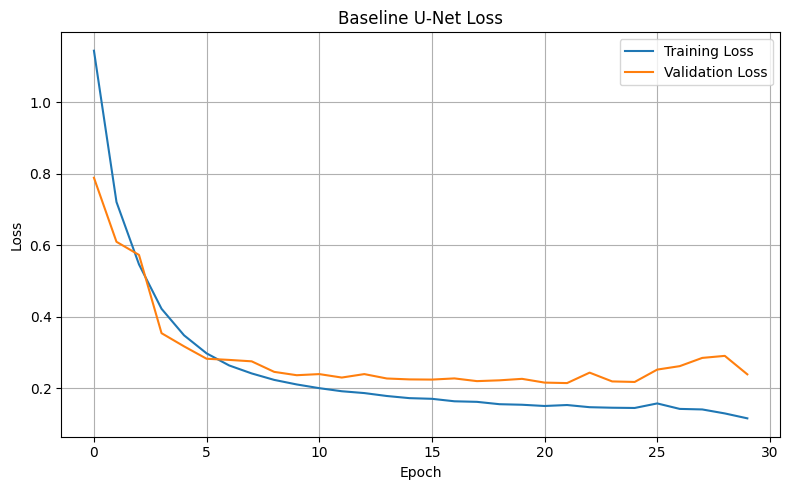

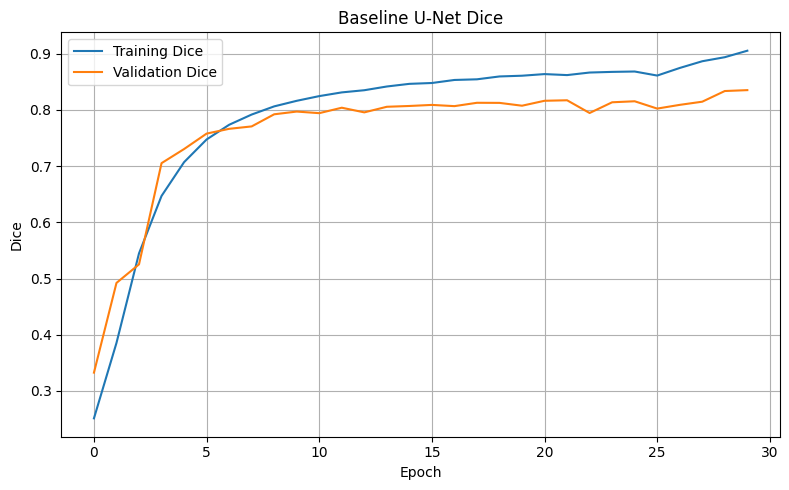

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline U-Net Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{RESULTS_DIR}/baseline_loss.png",
    dpi=200
)

plt.show()
plt.close()


plt.figure(figsize=(8, 5))

plt.plot(
    history.history["dice_metric"],
    label="Training Dice"
)

plt.plot(
    history.history["val_dice_metric"],
    label="Validation Dice"
)

plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("Baseline U-Net Dice")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{RESULTS_DIR}/baseline_dice.png",
    dpi=200
)

plt.show()
plt.close()

In [15]:
y_pred_prob = model.predict(
    X_val,
    batch_size=BATCH_SIZE,
    verbose=1
)

y_pred = np.argmax(
    y_pred_prob,
    axis=-1
)

print("Prediction shape:", y_pred.shape)
print("Prediction classes:", np.unique(y_pred))

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step
Prediction shape: (400, 256, 256)
Prediction classes: [0 1 2 3]


In [16]:
def calculate_dice(
    y_true,
    y_pred,
    class_id,
    smooth=1e-6
):

    true_mask = y_true == class_id
    pred_mask = y_pred == class_id

    intersection = np.sum(
        true_mask & pred_mask
    )

    return (
        2 * intersection + smooth
    ) / (
        np.sum(true_mask)
        + np.sum(pred_mask)
        + smooth
    )


def calculate_iou(
    y_true,
    y_pred,
    class_id,
    smooth=1e-6
):

    true_mask = y_true == class_id
    pred_mask = y_pred == class_id

    intersection = np.sum(
        true_mask & pred_mask
    )

    union = np.sum(
        true_mask | pred_mask
    )

    return (
        intersection + smooth
    ) / (
        union + smooth
    )

In [17]:
class_names = {
    0: "Background",
    1: "Right Ventricle (RV)",
    2: "Myocardium",
    3: "Left Ventricle (LV)"
}

dice_scores = {}
iou_scores = {}

for class_id, class_name in class_names.items():

    dice_scores[class_name] = calculate_dice(
        y_val,
        y_pred,
        class_id
    )

    iou_scores[class_name] = calculate_iou(
        y_val,
        y_pred,
        class_id
    )

    print(class_name)
    print(
        f"  Dice: {dice_scores[class_name]:.4f}"
    )
    print(
        f"  IoU : {iou_scores[class_name]:.4f}"
    )
    print()


mean_dice = np.mean(
    list(dice_scores.values())
)

mean_iou = np.mean(
    list(iou_scores.values())
)

cardiac_classes = [
    "Right Ventricle (RV)",
    "Myocardium",
    "Left Ventricle (LV)"
]

baseline_cardiac_dice = np.mean([
    dice_scores[c]
    for c in cardiac_classes
])

baseline_cardiac_iou = np.mean([
    iou_scores[c]
    for c in cardiac_classes
])

print("=" * 50)
print(f"Mean Dice: {mean_dice:.4f}")
print(f"Mean IoU : {mean_iou:.4f}")
print(f"Cardiac Dice: {baseline_cardiac_dice:.4f}")
print(f"Cardiac IoU : {baseline_cardiac_iou:.4f}")

Background
  Dice: 0.9974
  IoU : 0.9948

Right Ventricle (RV)
  Dice: 0.8564
  IoU : 0.7489

Myocardium
  Dice: 0.8541
  IoU : 0.7454

Left Ventricle (LV)
  Dice: 0.9431
  IoU : 0.8923

Mean Dice: 0.9128
Mean IoU : 0.8454
Cardiac Dice: 0.8846
Cardiac IoU : 0.7955


In [18]:
class_names = {
    0: "Background",
    1: "Right Ventricle (RV)",
    2: "Myocardium",
    3: "Left Ventricle (LV)"
}

dice_scores = {}
iou_scores = {}

for class_id, class_name in class_names.items():

    dice_scores[class_name] = calculate_dice(
        y_val,
        y_pred,
        class_id
    )

    iou_scores[class_name] = calculate_iou(
        y_val,
        y_pred,
        class_id
    )

    print(class_name)
    print(
        f"  Dice: {dice_scores[class_name]:.4f}"
    )
    print(
        f"  IoU : {iou_scores[class_name]:.4f}"
    )
    print()


mean_dice = np.mean(
    list(dice_scores.values())
)

mean_iou = np.mean(
    list(iou_scores.values())
)

cardiac_classes = [
    "Right Ventricle (RV)",
    "Myocardium",
    "Left Ventricle (LV)"
]

baseline_cardiac_dice = np.mean([
    dice_scores[c]
    for c in cardiac_classes
])

baseline_cardiac_iou = np.mean([
    iou_scores[c]
    for c in cardiac_classes
])

print("=" * 50)
print(f"Mean Dice: {mean_dice:.4f}")
print(f"Mean IoU : {mean_iou:.4f}")
print(f"Cardiac Dice: {baseline_cardiac_dice:.4f}")
print(f"Cardiac IoU : {baseline_cardiac_iou:.4f}")

Background
  Dice: 0.9974
  IoU : 0.9948

Right Ventricle (RV)
  Dice: 0.8564
  IoU : 0.7489

Myocardium
  Dice: 0.8541
  IoU : 0.7454

Left Ventricle (LV)
  Dice: 0.9431
  IoU : 0.8923

Mean Dice: 0.9128
Mean IoU : 0.8454
Cardiac Dice: 0.8846
Cardiac IoU : 0.7955


In [19]:
def dice_for_slice(
    y_true,
    y_pred,
    class_id,
    smooth=1e-6
):

    true_mask = y_true == class_id
    pred_mask = y_pred == class_id

    true_pixels = np.sum(true_mask)

    if true_pixels == 0:
        return None

    intersection = np.sum(
        true_mask & pred_mask
    )

    return (
        2 * intersection + smooth
    ) / (
        np.sum(true_mask)
        + np.sum(pred_mask)
        + smooth
    )


for class_id, class_name in {
    1: "Right Ventricle (RV)",
    2: "Myocardium",
    3: "Left Ventricle (LV)"
}.items():

    results = []

    for i in range(len(y_val)):

        score = dice_for_slice(
            y_val[i],
            y_pred[i],
            class_id
        )

        if score is not None:
            results.append(
                (i, score)
            )

    results.sort(
        key=lambda x: x[1]
    )

    print("\n" + "=" * 50)
    print(class_name)

    print("Worst 10 slices:")

    for index, score in results[:10]:

        print(
            f"Slice {index:3d}: "
            f"Dice = {score:.4f}"
        )


Right Ventricle (RV)
Worst 10 slices:
Slice 186: Dice = 0.0000
Slice 145: Dice = 0.0000
Slice 335: Dice = 0.0000
Slice 358: Dice = 0.0000
Slice 103: Dice = 0.0000
Slice 315: Dice = 0.0000
Slice 152: Dice = 0.0000
Slice 255: Dice = 0.0000
Slice 304: Dice = 0.0000
Slice 274: Dice = 0.0000

Myocardium
Worst 10 slices:
Slice 106: Dice = 0.0000
Slice 291: Dice = 0.0000
Slice 315: Dice = 0.0000
Slice 103: Dice = 0.0698
Slice  22: Dice = 0.2984
Slice 331: Dice = 0.3272
Slice   5: Dice = 0.4186
Slice 352: Dice = 0.4738
Slice 186: Dice = 0.5171
Slice 354: Dice = 0.5191

Left Ventricle (LV)
Worst 10 slices:
Slice  22: Dice = 0.0000
Slice 123: Dice = 0.0000
Slice 103: Dice = 0.0000
Slice 291: Dice = 0.0000
Slice 315: Dice = 0.0000
Slice   5: Dice = 0.0000
Slice  86: Dice = 0.1176
Slice 192: Dice = 0.1806
Slice 167: Dice = 0.1953
Slice 331: Dice = 0.3188


# Data Augmentation

The baseline model is trained without augmentation.

To investigate whether robustness can be improved, we apply:

- Horizontal flipping
- Vertical flipping
- MRI brightness variation

The segmentation mask is transformed together with the MRI image.

Brightness augmentation is applied only to the MRI image, not the mask.

In [20]:
def augment_pair(image, mask):

    if tf.random.uniform(()) > 0.5:

        image = tf.image.flip_left_right(image)

        mask = tf.image.flip_left_right(
            mask[..., tf.newaxis]
        )

        mask = tf.squeeze(
            mask,
            axis=-1
        )

    if tf.random.uniform(()) > 0.5:

        image = tf.image.flip_up_down(image)

        mask = tf.image.flip_up_down(
            mask[..., tf.newaxis]
        )

        mask = tf.squeeze(
            mask,
            axis=-1
        )

    image = tf.image.random_brightness(
        image,
        max_delta=0.05
    )

    image = tf.clip_by_value(
        image,
        0,
        1
    )

    return image, mask

In [21]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
)

train_dataset = (
    train_dataset
    .map(
        augment_pair,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    val_dataset
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Augmented training dataset ready.")

Augmented training dataset ready.


In [22]:
augmented_model = build_unet()

augmented_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=combined_loss,
    metrics=[dice_metric]
)

aug_history = augmented_model.fit(
    train_dataset,

    validation_data=val_dataset,

    epochs=40,

    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=1e-7
        )
    ],

    verbose=1
)

Epoch 1/40
189/189 ━━━━━━━━━━━━━━━━━━━━ 45s 176ms/step - dice_metric: 0.2495 - loss: 1.1477 - val_dice_metric: 0.3272 - val_loss: 0.8218 - learning_rate: 1.0000e-04
Epoch 2/40
189/189 ━━━━━━━━━━━━━━━━━━━━ 32s 170ms/step - dice_metric: 0.3493 - loss: 0.7679 - val_dice_metric: 0.3735 - val_loss: 0.7480 - learning_rate: 1.0000e-04
Epoch 3/40
189/189 ━━━━━━━━━━━━━━━━━━━━ 32s 168ms/step - dice_metric: 0.4221 - loss: 0.6903 - val_dice_metric: 0.4577 - val_loss: 0.6622 - learning_rate: 1.0000e-04
Epoch 4/40
189/189 ━━━━━━━━━━━━━━━━━━━━ 32s 169ms/step - dice_metric: 0.4717 - loss: 0.6347 - val_dice_metric: 0.5028 - val_loss: 0.5927 - learning_rate: 1.0000e-04
Epoch 5/40
189/189 ━━━━━━━━━━━━━━━━━━━━ 41s 169ms/step - dice_metric: 0.5336 - loss: 0.5604 - val_dice_metric: 0.5698 - val_loss: 0.5271 - learning_rate: 1.0000e-04
Epoch 6/40
189/189 ━━━━━━━━━━━━━━━━━━━━ 32s 169ms/step - dice_metric: 0.6267 - loss: 0.4479 - val_dice_metric: 0.6454 - val_loss: 0.4272 - learning_rate: 1.0000e-04
Epoch 7/40

In [23]:
aug_pred_prob = augmented_model.predict(
    X_val,
    batch_size=BATCH_SIZE,
    verbose=1
)

aug_pred = np.argmax(
    aug_pred_prob,
    axis=-1
)

aug_dice_scores = {}
aug_iou_scores = {}

for class_id, class_name in class_names.items():

    aug_dice_scores[class_name] = calculate_dice(
        y_val,
        aug_pred,
        class_id
    )

    aug_iou_scores[class_name] = calculate_iou(
        y_val,
        aug_pred,
        class_id
    )

    print(
        class_name,
        f"Dice: {aug_dice_scores[class_name]:.4f}",
        f"IoU: {aug_iou_scores[class_name]:.4f}"
    )


aug_mean_dice = np.mean(
    list(aug_dice_scores.values())
)

aug_mean_iou = np.mean(
    list(aug_iou_scores.values())
)

augmented_cardiac_dice = np.mean([
    aug_dice_scores[c]
    for c in cardiac_classes
])

augmented_cardiac_iou = np.mean([
    aug_iou_scores[c]
    for c in cardiac_classes
])

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step
Background Dice: 0.9975 IoU: 0.9951
Right Ventricle (RV) Dice: 0.8661 IoU: 0.7639
Myocardium Dice: 0.8713 IoU: 0.7719
Left Ventricle (LV) Dice: 0.9461 IoU: 0.8977


In [24]:
comparison = pd.DataFrame({

    "Class": cardiac_classes,

    "Baseline Dice": [
        dice_scores[c]
        for c in cardiac_classes
    ],

    "Augmented Dice": [
        aug_dice_scores[c]
        for c in cardiac_classes
    ],

    "Baseline IoU": [
        iou_scores[c]
        for c in cardiac_classes
    ],

    "Augmented IoU": [
        aug_iou_scores[c]
        for c in cardiac_classes
    ]
})

display(comparison)

,Class,Baseline Dice,Augmented Dice,Baseline IoU,Augmented IoU
0,Right Ventricle (RV),0.856449,0.866123,0.748939,0.763860
1,Myocardium,0.854104,0.871253,0.745359,0.771875
2,Left Ventricle (LV),0.943098,0.946111,0.892323,0.897733


In [25]:
print("=" * 60)

print(
    f"Baseline cardiac Dice: "
    f"{baseline_cardiac_dice:.4f}"
)

print(
    f"Augmented cardiac Dice: "
    f"{augmented_cardiac_dice:.4f}"
)

print(
    f"Dice improvement: "
    f"{augmented_cardiac_dice - baseline_cardiac_dice:+.4f}"
)

print()

print(
    f"Baseline cardiac IoU: "
    f"{baseline_cardiac_iou:.4f}"
)

print(
    f"Augmented cardiac IoU: "
    f"{augmented_cardiac_iou:.4f}"
)

print(
    f"IoU improvement: "
    f"{augmented_cardiac_iou - baseline_cardiac_iou:+.4f}"
)

Baseline cardiac Dice: 0.8846
Augmented cardiac Dice: 0.8945
Dice improvement: +0.0099

Baseline cardiac IoU: 0.7955
Augmented cardiac IoU: 0.8112
IoU improvement: +0.0156


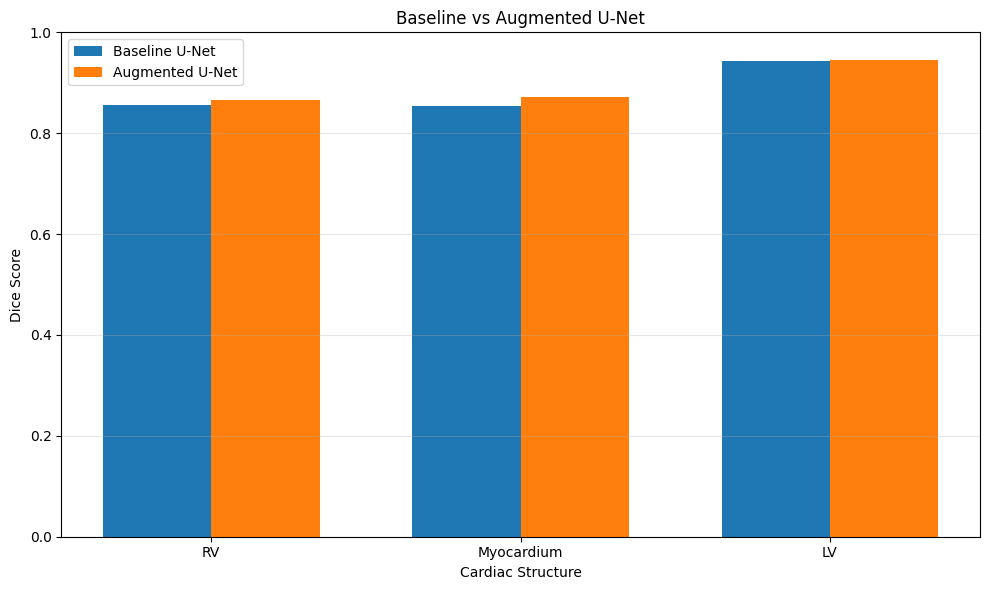

In [26]:
x = np.arange(len(cardiac_classes))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    comparison["Baseline Dice"],
    width,
    label="Baseline U-Net"
)

plt.bar(
    x + width/2,
    comparison["Augmented Dice"],
    width,
    label="Augmented U-Net"
)

plt.xticks(
    x,
    ["RV", "Myocardium", "LV"]
)

plt.ylabel("Dice Score")
plt.xlabel("Cardiac Structure")
plt.title("Baseline vs Augmented U-Net")

plt.ylim(0, 1)
plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    f"{RESULTS_DIR}/dice_comparison.png",
    dpi=200
)

plt.show()
plt.close()

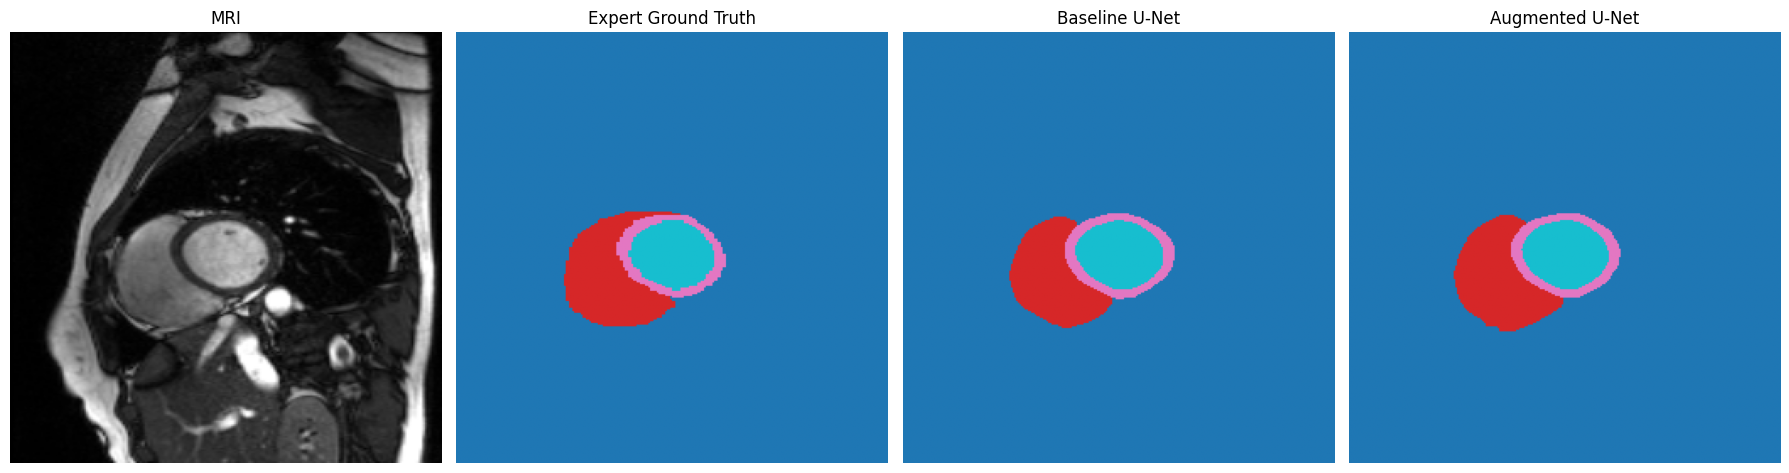

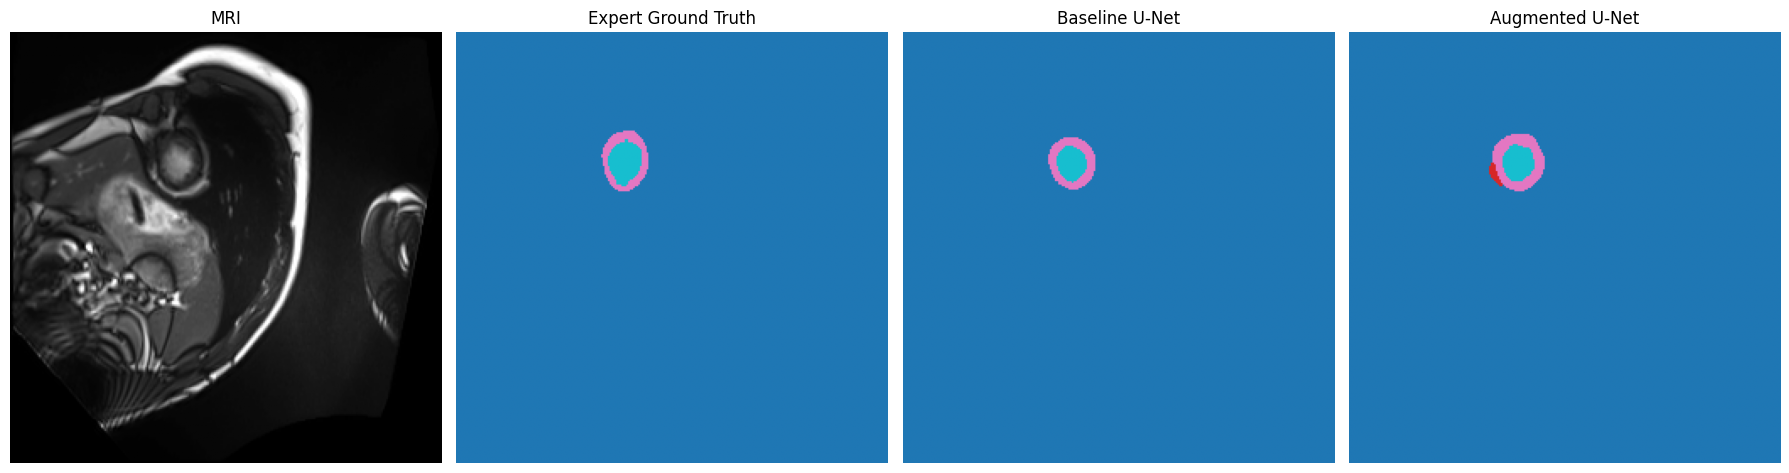

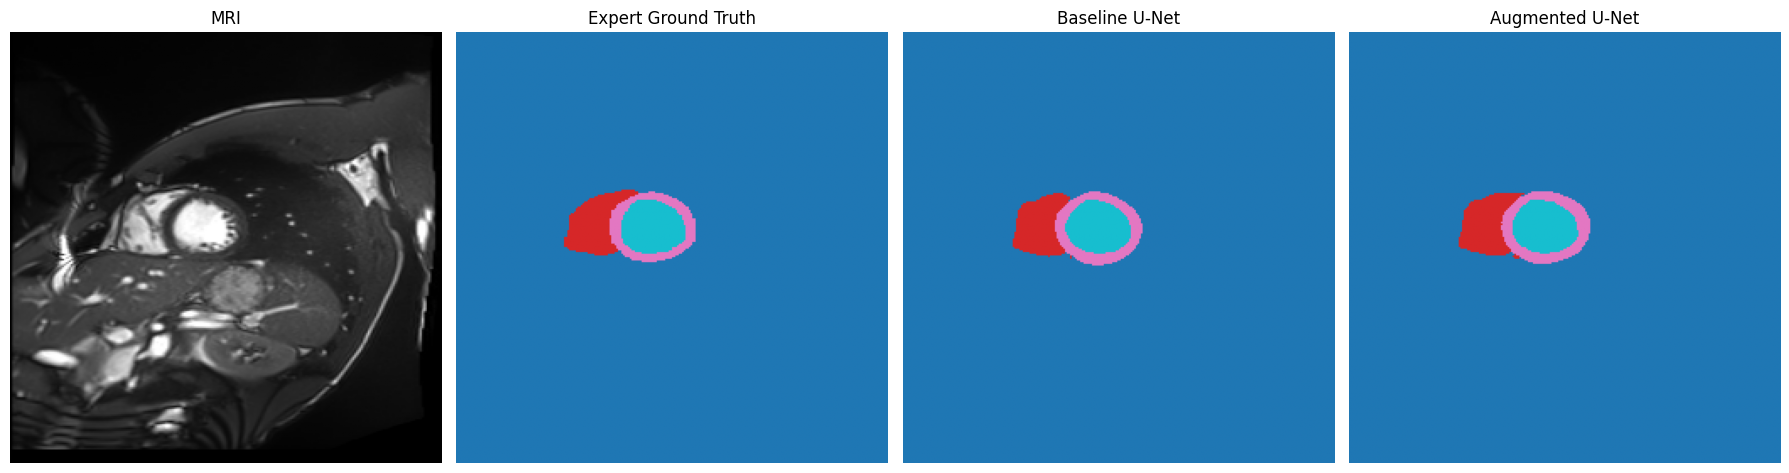

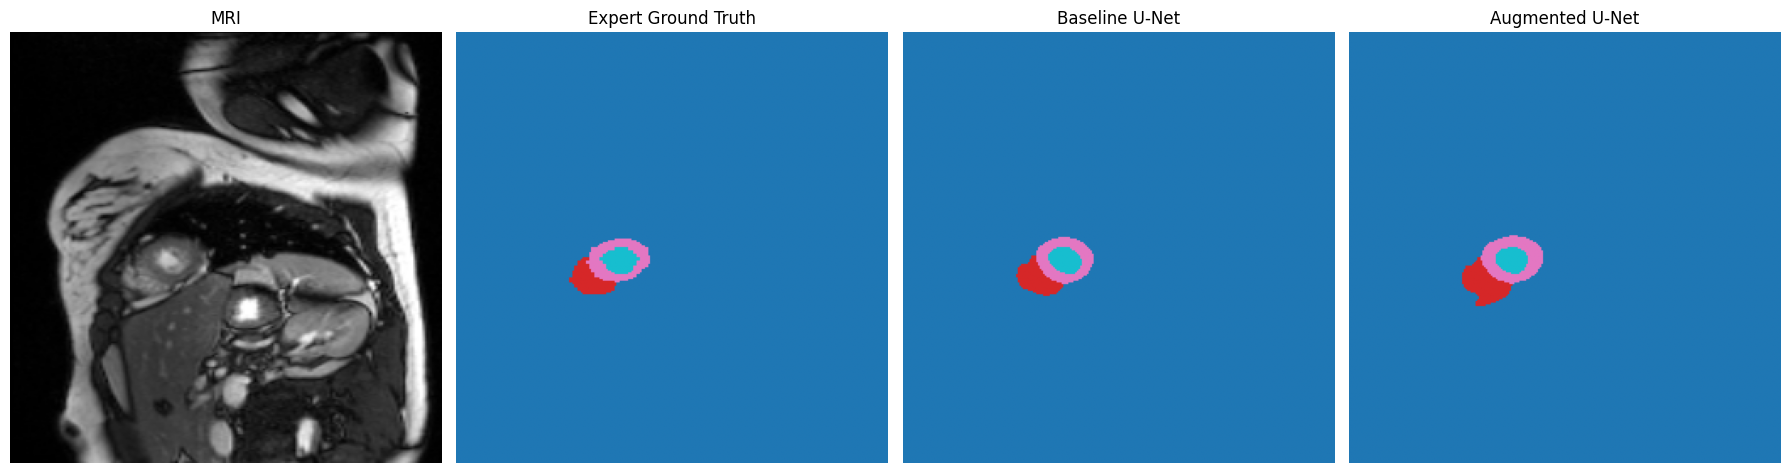

In [27]:
sample_indices = [20, 100, 200, 300]

for index in sample_indices:

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(18, 5)
    )

    axes[0].imshow(
        X_val[index].squeeze(),
        cmap="gray"
    )
    axes[0].set_title("MRI")

    axes[1].imshow(
        y_val[index],
        cmap="tab10",
        vmin=0,
        vmax=3
    )
    axes[1].set_title("Expert Ground Truth")

    axes[2].imshow(
        y_pred[index],
        cmap="tab10",
        vmin=0,
        vmax=3
    )
    axes[2].set_title("Baseline U-Net")

    axes[3].imshow(
        aug_pred[index],
        cmap="tab10",
        vmin=0,
        vmax=3
    )
    axes[3].set_title("Augmented U-Net")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()

    plt.savefig(
        f"{RESULTS_DIR}/comparison_{index}.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

In [28]:
final_comparison = pd.DataFrame({

    "Experiment": [
        "Baseline U-Net",
        "Augmented U-Net"
    ],

    "Mean Dice": [
        mean_dice,
        aug_mean_dice
    ],

    "Mean IoU": [
        mean_iou,
        aug_mean_iou
    ],

    "Cardiac Dice": [
        baseline_cardiac_dice,
        augmented_cardiac_dice
    ],

    "Cardiac IoU": [
        baseline_cardiac_iou,
        augmented_cardiac_iou
    ]
})

display(final_comparison)

final_comparison.to_csv(
    f"{RESULTS_DIR}/final_results.csv",
    index=False
)

comparison.to_csv(
    f"{RESULTS_DIR}/class_comparison.csv",
    index=False
)

print("Results saved.")

,Experiment,Mean Dice,Mean IoU,Cardiac Dice,Cardiac IoU
0,Baseline U-Net,0.912761,0.845355,0.884550,0.795540
1,Augmented U-Net,0.920252,0.857131,0.894495,0.811156


Results saved.


In [29]:
model.save(
    f"{RESULTS_DIR}/acdc_unet_baseline.keras"
)

augmented_model.save(
    f"{RESULTS_DIR}/acdc_unet_augmented.keras"
)

print("Both models saved.")

Both models saved.


# 5-Fold Cross-Validation Results

To evaluate the robustness and generalizability of the proposed U-Net segmentation model, 5-fold patient-level cross-validation was performed.

Patients were divided into five folds, ensuring that slices from the same patient were not distributed between training and validation sets.

For each fold, Dice scores were calculated separately for:

- Right Ventricle (RV)
- Myocardium
- Left Ventricle (LV)

The mean cardiac Dice score was then calculated across the three cardiac structures.

Results directory ready.

STARTING 5-FOLD CROSS-VALIDATION
Total patients: 100

FOLD 1/5
Training patients: 80
Validation patients: 20
Training slices: 1512
Validation slices: 400
Epoch 1/40
189/189 ━━━━━━━━━━━━━━━━━━━━ 42s 161ms/step - dice_metric: 0.2604 - loss: 1.0980 - val_dice_metric: 0.3422 - val_loss: 0.7792 - learning_rate: 1.0000e-04
Epoch 2/40
189/189 ━━━━━━━━━━━━━━━━━━━━ 30s 157ms/step - dice_metric: 0.3640 - loss: 0.7394 - val_dice_metric: 0.4289 - val_loss: 0.6689 - learning_rate: 1.0000e-04
Epoch 3/40
189/189 ━━━━━━━━━━━━━━━━━━━━ 30s 160ms/step - dice_metric: 0.5080 - loss: 0.5879 - val_dice_metric: 0.5814 - val_loss: 0.5036 - learning_rate: 1.0000e-04
Epoch 4/40
189/189 ━━━━━━━━━━━━━━━━━━━━ 31s 163ms/step - dice_metric: 0.6296 - loss: 0.4447 - val_dice_metric: 0.6803 - val_loss: 0.3900 - learning_rate: 1.0000e-04
Epoch 5/40
189/189 ━━━━━━━━━━━━━━━━━━━━ 31s 165ms/step - dice_metric: 0.7084 - loss: 0.3462 - val_dice_metric: 0.7314 - val_loss: 0.3192 - learning_rate: 1.0000

2026-08-25 07:35:14.585338: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 07:35:14.816154: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 07:35:15.974749: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 07:35:16.133734: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 07:35:18.589834: E external/local_xla/xla/stream_

195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - dice_metric: 0.1953 - loss: 1.5512

2026-08-25 07:35:41.080302: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 07:35:41.305710: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 07:35:42.093845: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 07:35:42.248530: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


195/195 ━━━━━━━━━━━━━━━━━━━━ 76s 330ms/step - dice_metric: 0.2531 - loss: 1.1229 - val_dice_metric: 0.3324 - val_loss: 0.7850 - learning_rate: 1.0000e-04
Epoch 2/40
195/195 ━━━━━━━━━━━━━━━━━━━━ 32s 165ms/step - dice_metric: 0.3862 - loss: 0.7189 - val_dice_metric: 0.4504 - val_loss: 0.6537 - learning_rate: 1.0000e-04
Epoch 3/40
195/195 ━━━━━━━━━━━━━━━━━━━━ 33s 167ms/step - dice_metric: 0.5427 - loss: 0.5467 - val_dice_metric: 0.6116 - val_loss: 0.4672 - learning_rate: 1.0000e-04
Epoch 4/40
195/195 ━━━━━━━━━━━━━━━━━━━━ 32s 166ms/step - dice_metric: 0.6611 - loss: 0.4049 - val_dice_metric: 0.6652 - val_loss: 0.4156 - learning_rate: 1.0000e-04
Epoch 5/40
195/195 ━━━━━━━━━━━━━━━━━━━━ 32s 166ms/step - dice_metric: 0.7154 - loss: 0.3381 - val_dice_metric: 0.7174 - val_loss: 0.3359 - learning_rate: 1.0000e-04
Epoch 6/40
195/195 ━━━━━━━━━━━━━━━━━━━━ 32s 166ms/step - dice_metric: 0.7485 - loss: 0.2971 - val_dice_metric: 0.7332 - val_loss: 0.3205 - learning_rate: 1.0000e-04
Epoch 7/40
195/195 ━━

2026-08-25 08:22:10.912399: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 08:22:11.139765: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 08:22:12.135882: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 08:22:12.293267: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 08:22:14.422324: E external/local_xla/xla/stream_

190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - dice_metric: 0.2003 - loss: 1.4935

2026-08-25 08:22:35.028287: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 08:22:35.255081: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


190/190 ━━━━━━━━━━━━━━━━━━━━ 71s 315ms/step - dice_metric: 0.2529 - loss: 1.1034 - val_dice_metric: 0.3180 - val_loss: 0.8015 - learning_rate: 1.0000e-04
Epoch 2/40
190/190 ━━━━━━━━━━━━━━━━━━━━ 32s 167ms/step - dice_metric: 0.3689 - loss: 0.7345 - val_dice_metric: 0.4242 - val_loss: 0.6791 - learning_rate: 1.0000e-04
Epoch 3/40
190/190 ━━━━━━━━━━━━━━━━━━━━ 32s 168ms/step - dice_metric: 0.5176 - loss: 0.5816 - val_dice_metric: 0.5652 - val_loss: 0.5282 - learning_rate: 1.0000e-04
Epoch 4/40
190/190 ━━━━━━━━━━━━━━━━━━━━ 32s 167ms/step - dice_metric: 0.6334 - loss: 0.4416 - val_dice_metric: 0.6733 - val_loss: 0.3947 - learning_rate: 1.0000e-04
Epoch 5/40
190/190 ━━━━━━━━━━━━━━━━━━━━ 32s 168ms/step - dice_metric: 0.7101 - loss: 0.3451 - val_dice_metric: 0.7094 - val_loss: 0.3510 - learning_rate: 1.0000e-04
Epoch 6/40
190/190 ━━━━━━━━━━━━━━━━━━━━ 32s 168ms/step - dice_metric: 0.7504 - loss: 0.2949 - val_dice_metric: 0.7297 - val_loss: 0.3249 - learning_rate: 1.0000e-04
Epoch 7/40
190/190 ━━

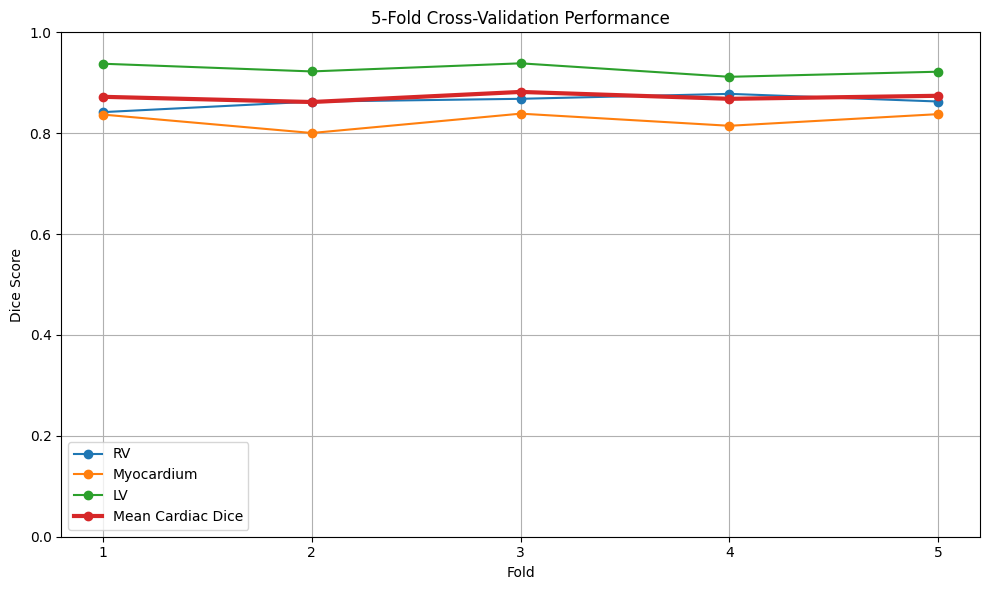


EXPERIMENT COMPARISON
             Experiment  Cardiac Dice  Dice Std
         Baseline U-Net      0.884550       NaN
        Augmented U-Net      0.894495       NaN
5-Fold Cross-Validation      0.871649  0.007399


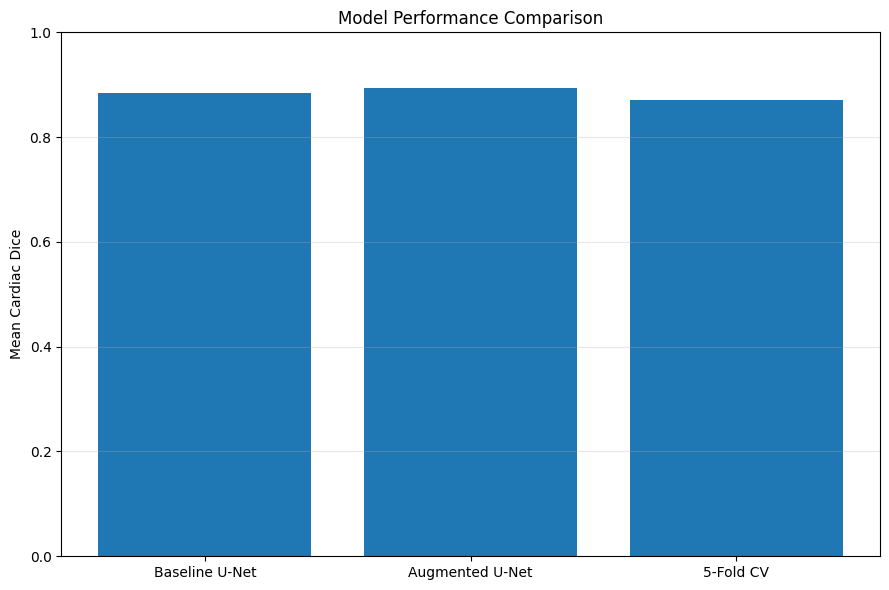


CARDIAC AREA ANALYSIS

Mean LV Area
Expert: 879.53
Predicted: 897.9

Mean RV Area
Expert: 736.29
Predicted: 696.39

Mean Myocardium Area
Expert: 902.72
Predicted: 905.48

ERROR ANALYSIS
               Class  Mean Dice  Minimum Dice  Dice < 0.5  Dice < 0.7
          Background   0.997387  9.838494e-01           0           0
Right Ventricle (RV)   0.786841  8.403361e-10          37          57
          Myocardium   0.832484  5.235602e-09           8          34
 Left Ventricle (LV)   0.897636  5.917160e-09          14          24


FINAL PROJECT RESULTS
Baseline Cardiac Dice : 0.8846
Augmented Cardiac Dice: 0.8945
5-Fold Cardiac Dice   : 0.8716 ± 0.0074

Augmentation improvement: +0.0099

All analysis completed.

Results saved in:
/kaggle/working/results


In [34]:
# ============================================================
# COMPLETE FINAL ANALYSIS
# 5-Fold CV + Model Comparison + Area Analysis + Error Analysis
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import KFold

# ============================================================
# 1. Create results folder
# ============================================================

RESULTS_DIR = "/kaggle/working/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Results directory ready.")


# ============================================================
# 2. START 5-FOLD PATIENT-LEVEL CROSS-VALIDATION
# ============================================================

unique_patients = np.unique(patient_ids)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_results = []

print("\n" + "=" * 60)
print("STARTING 5-FOLD CROSS-VALIDATION")
print("=" * 60)

print("Total patients:", len(unique_patients))


# ============================================================
# 3. RUN 5 FOLDS
# ============================================================

for fold, (train_idx, val_idx) in enumerate(
    kf.split(unique_patients),
    start=1
):

    print("\n" + "=" * 60)
    print(f"FOLD {fold}/5")
    print("=" * 60)

    # --------------------------------------------------------
    # Patient-level split
    # --------------------------------------------------------

    fold_train_patients = unique_patients[train_idx]
    fold_val_patients = unique_patients[val_idx]

    train_mask = np.isin(
        patient_ids,
        fold_train_patients
    )

    val_mask = np.isin(
        patient_ids,
        fold_val_patients
    )

    X_fold_train = images[train_mask]
    y_fold_train = labels[train_mask]

    X_fold_val = images[val_mask]
    y_fold_val = labels[val_mask]

    print(
        "Training patients:",
        len(fold_train_patients)
    )

    print(
        "Validation patients:",
        len(fold_val_patients)
    )

    print(
        "Training slices:",
        len(X_fold_train)
    )

    print(
        "Validation slices:",
        len(X_fold_val)
    )


    # --------------------------------------------------------
    # Normalize using training fold only
    # --------------------------------------------------------

    fold_min = X_fold_train.min()
    fold_max = X_fold_train.max()

    X_fold_train = (
        X_fold_train - fold_min
    ) / (
        fold_max - fold_min + 1e-8
    )

    X_fold_val = (
        X_fold_val - fold_min
    ) / (
        fold_max - fold_min + 1e-8
    )


    # --------------------------------------------------------
    # Add channel dimension
    # --------------------------------------------------------

    X_fold_train = X_fold_train[..., np.newaxis]
    X_fold_val = X_fold_val[..., np.newaxis]


    # --------------------------------------------------------
    # TensorFlow datasets
    # --------------------------------------------------------

    fold_train_ds = tf.data.Dataset.from_tensor_slices(
        (X_fold_train, y_fold_train)
    )

    fold_val_ds = tf.data.Dataset.from_tensor_slices(
        (X_fold_val, y_fold_val)
    )

    fold_train_ds = (
        fold_train_ds
        .shuffle(1000)
        .batch(8)
        .prefetch(tf.data.AUTOTUNE)
    )

    fold_val_ds = (
        fold_val_ds
        .batch(8)
        .prefetch(tf.data.AUTOTUNE)
    )


    # --------------------------------------------------------
    # Create fresh U-Net
    # --------------------------------------------------------

    fold_model = build_unet(
        input_shape=(256, 256, 1),
        num_classes=4
    )

    fold_model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-4
        ),
        loss=combined_loss,
        metrics=[dice_metric]
    )


    # --------------------------------------------------------
    # Callbacks
    # --------------------------------------------------------

    fold_callbacks = [

        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=1e-6,
            verbose=1
        )
    ]


    # --------------------------------------------------------
    # Train fold
    # --------------------------------------------------------

    history = fold_model.fit(
        fold_train_ds,
        validation_data=fold_val_ds,
        epochs=40,
        callbacks=fold_callbacks,
        verbose=1
    )


    # --------------------------------------------------------
    # Predict validation fold
    # --------------------------------------------------------

    fold_pred_prob = fold_model.predict(
        X_fold_val,
        batch_size=8,
        verbose=0
    )

    fold_pred = np.argmax(
        fold_pred_prob,
        axis=-1
    )


    # --------------------------------------------------------
    # Calculate Dice for cardiac structures
    # --------------------------------------------------------

    fold_dice = []

    for class_id in [1, 2, 3]:

        true_mask = (
            y_fold_val == class_id
        )

        pred_mask = (
            fold_pred == class_id
        )

        intersection = np.sum(
            true_mask & pred_mask
        )

        dice = (
            2 * intersection + 1e-6
        ) / (
            np.sum(true_mask)
            +
            np.sum(pred_mask)
            +
            1e-6
        )

        fold_dice.append(dice)


    fold_mean_dice = np.mean(
        fold_dice
    )


    # --------------------------------------------------------
    # Save fold result
    # --------------------------------------------------------

    fold_results.append({

        "Fold": fold,

        "RV Dice":
            fold_dice[0],

        "Myocardium Dice":
            fold_dice[1],

        "LV Dice":
            fold_dice[2],

        "Mean Cardiac Dice":
            fold_mean_dice
    })


    print(
        f"\nFold {fold} Cardiac Dice: "
        f"{fold_mean_dice:.4f}"
    )


    # --------------------------------------------------------
    # Clear model from memory
    # --------------------------------------------------------

    del fold_model

    tf.keras.backend.clear_session()


print("\n" + "=" * 60)
print("5-FOLD CROSS-VALIDATION COMPLETED")
print("=" * 60)


# ============================================================
# 4. CROSS-VALIDATION RESULTS
# ============================================================

cv_results = pd.DataFrame(
    fold_results
)

print("\nFold Results:")
print(
    cv_results.to_string(
        index=False
    )
)


# ============================================================
# 5. CROSS-VALIDATION SUMMARY
# ============================================================

cv_summary = pd.DataFrame({

    "Metric": [
        "RV Dice",
        "Myocardium Dice",
        "LV Dice",
        "Mean Cardiac Dice"
    ],

    "Mean": [
        cv_results["RV Dice"].mean(),
        cv_results["Myocardium Dice"].mean(),
        cv_results["LV Dice"].mean(),
        cv_results["Mean Cardiac Dice"].mean()
    ],

    "Std": [
        cv_results["RV Dice"].std(),
        cv_results["Myocardium Dice"].std(),
        cv_results["LV Dice"].std(),
        cv_results["Mean Cardiac Dice"].std()
    ]
})


print("\n" + "=" * 60)
print("5-FOLD CROSS-VALIDATION SUMMARY")
print("=" * 60)

for _, row in cv_summary.iterrows():

    print(
        f"{row['Metric']}: "
        f"{row['Mean']:.4f} ± "
        f"{row['Std']:.4f}"
    )


# ============================================================
# 6. SAVE CV RESULTS
# ============================================================

cv_results.to_csv(
    f"{RESULTS_DIR}/cross_validation_folds.csv",
    index=False
)

cv_summary.to_csv(
    f"{RESULTS_DIR}/cross_validation_summary.csv",
    index=False
)

print("\nCross-validation CSV files saved.")


# ============================================================
# 7. CROSS-VALIDATION DICE PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    cv_results["Fold"],
    cv_results["RV Dice"],
    marker="o",
    label="RV"
)

plt.plot(
    cv_results["Fold"],
    cv_results["Myocardium Dice"],
    marker="o",
    label="Myocardium"
)

plt.plot(
    cv_results["Fold"],
    cv_results["LV Dice"],
    marker="o",
    label="LV"
)

plt.plot(
    cv_results["Fold"],
    cv_results["Mean Cardiac Dice"],
    marker="o",
    linewidth=3,
    label="Mean Cardiac Dice"
)

plt.xlabel("Fold")
plt.ylabel("Dice Score")
plt.title(
    "5-Fold Cross-Validation Performance"
)

plt.xticks(
    [1, 2, 3, 4, 5]
)

plt.ylim(
    0,
    1
)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{RESULTS_DIR}/cross_validation_dice.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 8. BASELINE vs AUGMENTED vs CV
# ============================================================

experiment_summary = pd.DataFrame({

    "Experiment": [
        "Baseline U-Net",
        "Augmented U-Net",
        "5-Fold Cross-Validation"
    ],

    "Cardiac Dice": [
        baseline_cardiac_dice,
        augmented_cardiac_dice,
        cv_results[
            "Mean Cardiac Dice"
        ].mean()
    ],

    "Dice Std": [
        np.nan,
        np.nan,
        cv_results[
            "Mean Cardiac Dice"
        ].std()
    ]
})


print("\n" + "=" * 60)
print("EXPERIMENT COMPARISON")
print("=" * 60)

print(
    experiment_summary.to_string(
        index=False
    )
)


experiment_summary.to_csv(
    f"{RESULTS_DIR}/experiment_summary.csv",
    index=False
)


# ============================================================
# 9. OVERALL MODEL COMPARISON PLOT
# ============================================================

values = [
    baseline_cardiac_dice,
    augmented_cardiac_dice,
    cv_results[
        "Mean Cardiac Dice"
    ].mean()
]

labels = [
    "Baseline U-Net",
    "Augmented U-Net",
    "5-Fold CV"
]

plt.figure(figsize=(9, 6))

plt.bar(
    labels,
    values
)

plt.ylabel(
    "Mean Cardiac Dice"
)

plt.title(
    "Model Performance Comparison"
)

plt.ylim(
    0,
    1
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    f"{RESULTS_DIR}/overall_model_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 10. CARDIAC AREA ANALYSIS
# ============================================================

def calculate_structure_area(
    mask,
    class_id
):

    return np.sum(
        mask == class_id
    )


area_results = []


for i in range(
    len(y_val)
):

    true_lv = calculate_structure_area(
        y_val[i],
        3
    )

    pred_lv = calculate_structure_area(
        y_pred[i],
        3
    )

    true_rv = calculate_structure_area(
        y_val[i],
        1
    )

    pred_rv = calculate_structure_area(
        y_pred[i],
        1
    )

    true_myocardium = calculate_structure_area(
        y_val[i],
        2
    )

    pred_myocardium = calculate_structure_area(
        y_pred[i],
        2
    )


    area_results.append({

        "Slice": i,

        "True LV Area":
            true_lv,

        "Predicted LV Area":
            pred_lv,

        "True RV Area":
            true_rv,

        "Predicted RV Area":
            pred_rv,

        "True Myocardium Area":
            true_myocardium,

        "Predicted Myocardium Area":
            pred_myocardium
    })


area_df = pd.DataFrame(
    area_results
)


print("\n" + "=" * 60)
print("CARDIAC AREA ANALYSIS")
print("=" * 60)

print(
    "\nMean LV Area"
)

print(
    "Expert:",
    round(
        area_df[
            "True LV Area"
        ].mean(),
        2
    )
)

print(
    "Predicted:",
    round(
        area_df[
            "Predicted LV Area"
        ].mean(),
        2
    )
)


print(
    "\nMean RV Area"
)

print(
    "Expert:",
    round(
        area_df[
            "True RV Area"
        ].mean(),
        2
    )
)

print(
    "Predicted:",
    round(
        area_df[
            "Predicted RV Area"
        ].mean(),
        2
    )
)


print(
    "\nMean Myocardium Area"
)

print(
    "Expert:",
    round(
        area_df[
            "True Myocardium Area"
        ].mean(),
        2
    )
)

print(
    "Predicted:",
    round(
        area_df[
            "Predicted Myocardium Area"
        ].mean(),
        2
    )
)


# Save area analysis

area_df.to_csv(
    f"{RESULTS_DIR}/cardiac_area_analysis.csv",
    index=False
)


# ============================================================
# 11. ERROR ANALYSIS
# ============================================================

error_summary = []


for class_id, class_name in class_names.items():

    scores = []


    for i in range(
        len(y_val)
    ):

        score = dice_for_slice(
            y_val[i],
            y_pred[i],
            class_id
        )

        if score is not None:

            scores.append(
                score
            )


    scores = np.array(
        scores
    )


    error_summary.append({

        "Class":
            class_name,

        "Mean Dice":
            scores.mean(),

        "Minimum Dice":
            scores.min(),

        "Dice < 0.5":
            np.sum(
                scores < 0.5
            ),

        "Dice < 0.7":
            np.sum(
                scores < 0.7
            )
    })


error_summary_df = pd.DataFrame(
    error_summary
)


print("\n" + "=" * 60)
print("ERROR ANALYSIS")
print("=" * 60)

print(
    error_summary_df.to_string(
        index=False
    )
)


# Save error analysis

error_summary_df.to_csv(
    f"{RESULTS_DIR}/error_analysis.csv",
    index=False
)


# ============================================================
# 12. FINAL SUMMARY
# ============================================================

final_cv_dice = cv_results[
    "Mean Cardiac Dice"
].mean()

final_cv_std = cv_results[
    "Mean Cardiac Dice"
].std()


print("\n")
print("=" * 70)
print("FINAL PROJECT RESULTS")
print("=" * 70)

print(
    f"Baseline Cardiac Dice : "
    f"{baseline_cardiac_dice:.4f}"
)

print(
    f"Augmented Cardiac Dice: "
    f"{augmented_cardiac_dice:.4f}"
)

print(
    f"5-Fold Cardiac Dice   : "
    f"{final_cv_dice:.4f} ± {final_cv_std:.4f}"
)

print(
    f"\nAugmentation improvement: "
    f"{augmented_cardiac_dice - baseline_cardiac_dice:+.4f}"
)

print("\nAll analysis completed.")

print(
    f"\nResults saved in:\n{RESULTS_DIR}"
)